<a href="https://colab.research.google.com/github/WTFjarux/Level-6--Artificial-Intelligence/blob/main/2438454_SurajPandey_Worksheet5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile

zip_path = "/content/drive/MyDrive/Level 6 - Aritficial Intelligence /Workshop 5/FruitinAmazon.zip"
extract_path = "/content/drive/MyDrive/Level 6 - Aritficial Intelligence /Workshop 5"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [3]:
import os
os.listdir("/content/drive/MyDrive/Level 6 - Aritficial Intelligence /Workshop 5")

['2438454_SurajPandey_Worksheet5.ipynb', 'FruitinAmazon.zip', 'FruitinAmazon']

In [5]:
os.listdir("/content/drive/MyDrive/Level 6 - Aritficial Intelligence /Workshop 5/FruitinAmazon")

['test', 'train']

In [6]:
from tensorflow.keras.callbacks import EarlyStopping

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from PIL import Image

# **TASK 1: DATA VISUALIZATION**

Classes: ['pupunha', 'acai', 'guarana', 'graviola', 'tucuma', 'cupuacu']


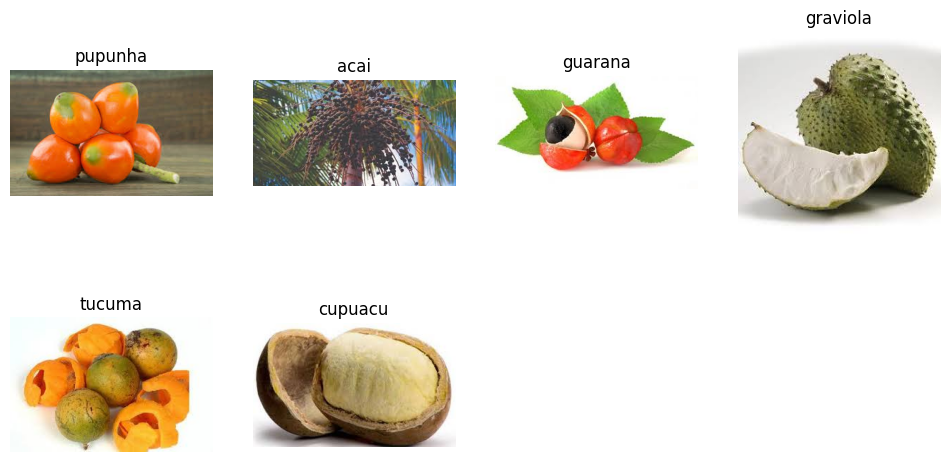

In [8]:
train_dir = "/content/drive/MyDrive/Level 6 - Aritficial Intelligence /Workshop 5/FruitinAmazon/train"

classes = os.listdir(train_dir)
print("Classes:", classes)

plt.figure(figsize=(12,6))

for i, cls in enumerate(classes):
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, len(classes)//2 + 1, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

Images belong to different fruit categories

Variation in color, shape, size

Some background noise exists

Dataset looks suitable for classification

# **REMOVE CORRUPTED IMAGES**

In [9]:
corrupted = []

for cls in os.listdir(train_dir):
    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print("Removed:", img_path)

if len(corrupted) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


# **LOAD DATASET**

In [14]:
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

def rescale(image, label):
    image = tf.cast(image, tf.float32)
    image /= 255.0
    return image, label

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# ✅ SAVE BEFORE map()
class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)

# THEN apply normalization
train_ds = train_ds.map(lambda x, y: rescale(x, y))
val_ds = val_ds.map(lambda x, y: rescale(x, y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


# **LOAD TEST DATA**

In [16]:
test_dir = "/content/drive/MyDrive/Level 6 - Aritficial Intelligence /Workshop 5/FruitinAmazon/test"  # must exist

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: rescale(x, y))

Found 30 files belonging to 6 classes.


# **BUILD CNN MODEL**

In [17]:
model = keras.Sequential([
    keras.Input(shape=(img_height, img_width, 3)),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

# **COMPILE + TRAIN**

In [18]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# **Callbacks**

In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.weights.h5",
    save_best_only=True,
    monitor='val_accuracy'
)

# **Train Model**

In [20]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.1950 - loss: 1.9476

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 657ms/step - accuracy: 0.1944 - loss: 2.0167 - val_accuracy: 0.0000e+00 - val_loss: 2.2243
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.2894 - loss: 1.7297

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 599ms/step - accuracy: 0.3056 - loss: 1.7414 - val_accuracy: 0.0556 - val_loss: 1.8190
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.3501 - loss: 1.5866

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 592ms/step - accuracy: 0.3472 - loss: 1.5672 - val_accuracy: 0.7222 - val_loss: 1.4679
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 555ms/step - accuracy: 0.5000 - loss: 1.3567 - val_accuracy: 0.6111 - val_loss: 1.3066
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5833 - loss: 1.1818 - val_accuracy: 0.6667 - val_loss: 0.9255
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 855ms/step - accuracy: 0.6111 - loss: 1.0252 - val_accuracy: 0.4444 - val_loss: 1.6706
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.6991 - loss: 0.9129

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 588ms/step - accuracy: 0.7222 - loss: 0.9303 - val_accuracy: 0.7778 - val_loss: 0.9564
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 530ms/step - accuracy: 0.7917 - loss: 0.7460 - val_accuracy: 0.7222 - val_loss: 0.8300
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.8420 - loss: 0.5578

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 671ms/step - accuracy: 0.7917 - loss: 0.6191 - val_accuracy: 0.8333 - val_loss: 0.5712
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 727ms/step - accuracy: 0.9028 - loss: 0.4295 - val_accuracy: 0.6667 - val_loss: 0.8120
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 523ms/step - accuracy: 0.9167 - loss: 0.3748 - val_accuracy: 0.3889 - val_loss: 1.1082
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 516ms/step - accuracy: 0.9167 - loss: 0.2668 - val_accuracy: 0.8333 - val_loss: 0.6624
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.9456 - loss: 0.2336

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 622ms/step - accuracy: 0.9306 - loss: 0.2405 - val_accuracy: 0.9444 - val_loss: 0.3393
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 518ms/step - accuracy: 1.0000 - loss: 0.0932 - val_accuracy: 0.6667 - val_loss: 0.6864
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 544ms/step - accuracy: 0.9861 - loss: 0.1231 - val_accuracy: 0.8333 - val_loss: 0.4191
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 839ms/step - accuracy: 1.0000 - loss: 0.0579 - val_accuracy: 0.8889 - val_loss: 0.3294
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 706ms/step - accuracy: 0.9861 - loss: 0.0507 - val_accuracy: 0.8889 - val_loss: 0.2320
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 510ms/step - accuracy: 0.9722 - loss: 0.0895 - val_accuracy: 0.9444 - val_loss: 0.1540
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 544ms/step - accuracy: 0.9861 - loss: 0.0386 - val_accuracy: 0.8889 - val_loss: 0.2669
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 494ms/step - accuracy: 0.9861 - loss: 0.0548 - val_accuracy: 0.8889 - val_lo

# **GRAPH**

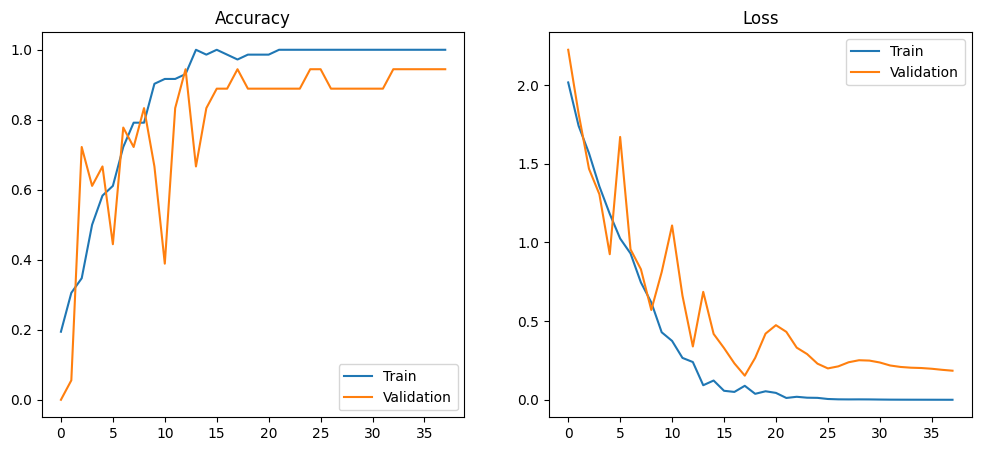

In [21]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(['Train', 'Validation'])

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(['Train', 'Validation'])

plt.show()

# **EVALUATE**

In [22]:
loss, accuracy = model.evaluate(val_ds)
print("Validation Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9444 - loss: 0.1540
Validation Accuracy: 0.9444444179534912


# **SAVE + LOAD MODEL**

In [23]:
model.save("fruit_model.keras")

loaded_model = keras.models.load_model("fruit_model.keras")

loaded_model.evaluate(val_ds)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 593ms/step - accuracy: 0.9444 - loss: 0.1540


[0.15403825044631958, 0.9444444179534912]

# **PREDICTIONS + CLASSIFICATION REPORT**

In [24]:
from sklearn.metrics import classification_report

y_true = []
y_pred_probs = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred_probs), axis=1)

print("Predicted:", [class_names[i] for i in y_pred[:5]])
print("Actual:", [class_names[i] for i in y_true[:5]])

print(classification_report(y_true, y_pred, target_names=class_names))


Predicted: ['cupuacu', 'cupuacu', 'acai', 'acai', 'acai']
Actual: ['acai', 'acai', 'acai', 'acai', 'acai']
              precision    recall  f1-score   support

        acai       0.60      0.60      0.60         5
     cupuacu       0.50      1.00      0.67         5
    graviola       1.00      1.00      1.00         5
     guarana       1.00      0.40      0.57         5
     pupunha       1.00      1.00      1.00         5
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.73        30
   macro avg       0.79      0.73      0.72        30
weighted avg       0.79      0.73      0.72        30



# **CONFUSION MATRIX**

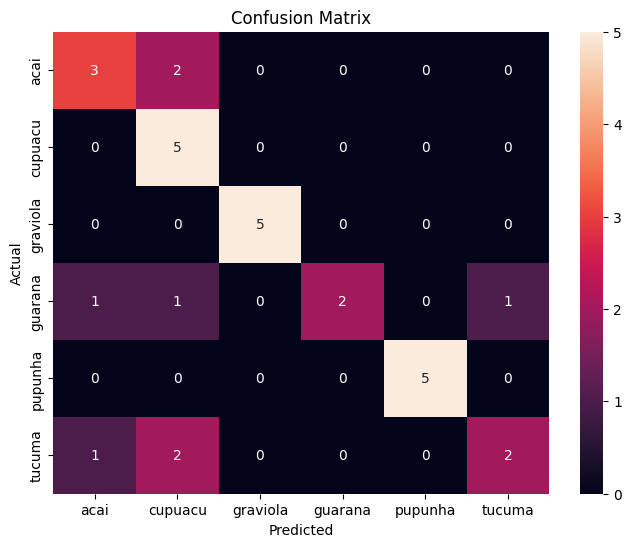

In [25]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()